# GECS Industry & Sub-Industry Classification — Data Cleaning Pipeline

**Project:** DePaul × Morningstar Capstone (Spring 2026)
**Author:** Meet Patel — Analytics & Modeling Lead
**Notebook:** `01_cleaning.ipynb` (v3)
**Last Updated:** April 2026

---

## Overview

This notebook performs end-to-end cleaning on the Morningstar GECS classification datasets in
preparation for downstream modeling. It is designed to be run for **either Task 1 or Task 2** by
flipping the `TASK` flag in the Config cell.

| Task | Goal | Records | Date Range | Target | Classes |
|------|------|---------|-----------|--------|---------|
| 1 | Industry classification (company-level) | 53,585 | 2003-12-31 → 2024-12-31 | `MstarGlobal` | 145 |
| 2 | Business activity classification (segment-level) | 27,537 | 2020-05-31 → 2024-12-31 | `SubIndustry` | 450 |

## Pipeline Steps

1. Load raw data
2. Schema validation
3. Initial null audit
4. Drop invalid rows (null IDs, bad dates, out-of-range dates, null labels)
5. Extract GECS hierarchy (Task 1 only)
6. Text normalization
7. Fill nulls in `SegmentName` and `SegmentDescription`
8. Fix numeric columns (Task 1 only)
9. Drop duplicates
10. Build `combined_text` field
11. Engineer features
12. (Scaling deferred to modeling notebook — prevents leakage)
13. Rare-class diagnostic
14. Final null audit
15. Cleaning summary
16. Save cleaned data

## How to Run

1. Set `TASK = 1` or `TASK = 2` in the Config cell
2. Confirm `INPUT_PATH` points to your raw CSV
3. **Kernel → Restart & Run All**

## Design Decisions

- **Missingness flags before fill:** `segment_desc_missing` is set *before* imputation so
  downstream models can distinguish original vs imputed text.
- **No scaling here:** `StandardScaler` is fit inside the modeling pipeline on training data only.
- **Diagnostic columns prefixed `_diag_`:** label-derived columns are clearly marked so they are
  not accidentally used as model features (would cause label leakage).
- **Parquet output:** preserves dtypes (categoricals, datetimes, bools) and loads ~10× faster
  than CSV in the modeling notebook.

---
## 0. Imports & Environment Setup

In [19]:
# Standard library
import os
import re
import html
import warnings
from pathlib import Path

# Numerical / data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns',  30)
pd.set_option('display.width',        200)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']        = 100
plt.rcParams['savefig.dpi']       = 150
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top']   = False

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'Random seed : {RANDOM_SEED}')

pandas      : 3.0.2
numpy       : 2.4.4
Random seed : 42


---
## 1. Configuration

Change `TASK` to switch between the two classification problems. All other paths and constants
are derived from this single flag.

In [20]:
# ───────────────────────────── USER SETTINGS ─────────────────────────────
TASK = 2                         # 1 = Industry, 2 = Sub-Industry
DATA_DIR = Path('../data')         # adjust if your folder structure differs
# ─────────────────────────────────────────────────────────────────────────

# Derived configuration
if TASK == 1:
    FILE_NAME  = 'task1_gecs_classification_final.csv'
    LABEL_COL  = 'MstarGlobal'
    N_CLASSES  = 145
    DATE_RANGE = ('2003-12-31', '2024-12-31')
elif TASK == 2:
    FILE_NAME  = 'task2_subindustry_classification_final.csv'
    LABEL_COL  = 'SubIndustry'
    N_CLASSES  = 450
    DATE_RANGE = ('2020-05-31', '2024-12-31')
else:
    raise ValueError(f'TASK must be 1 or 2, got {TASK}')

INPUT_PATH  = DATA_DIR / 'raw'     / FILE_NAME
OUTPUT_PATH = DATA_DIR / 'cleaned' / FILE_NAME.replace('.csv', '_cleaned.parquet')
SUMMARY_PATH = DATA_DIR / 'cleaned' / f'task{TASK}_cleaning_summary.txt'

# Required schema per task
TASK1_COLS = [
    'CompanyId', 'AsOfDate', 'LongProfile', 'SegmentName', 'SegmentDescription',
    'Revenue', 'total_revenue_company_as_of', 'revenue_share',
    'is_largest_share_segment', 'MstarGlobal',
]
TASK2_COLS = [
    'CompanyId', 'AsOfDate', 'SegmentName', 'SegmentDescription', 'SubIndustry',
]
REQUIRED_COLS = TASK1_COLS if TASK == 1 else TASK2_COLS

# GECS hierarchy reference maps (Task 1)
SECTOR_MAP = {
    '101': 'Basic Materials',     '102': 'Consumer Cyclical',
    '103': 'Financial Services',  '104': 'Real Estate',
    '205': 'Consumer Defensive',  '206': 'Healthcare',
    '207': 'Utilities',           '308': 'Communication Services',
    '309': 'Energy',              '310': 'Industrials',
    '311': 'Technology',
}
SUPER_SECTOR_MAP = {'1': 'Cyclical', '2': 'Defensive', '3': 'Sensitive'}

# Cleaning log — every drop / fix recorded for the final summary
log = {
    'raw_rows':                  0,
    'dropped_companyid':         0,
    'dropped_bad_dates':         0,
    'dropped_oor_dates':         0,
    'dropped_null_label':        0,
    'dropped_duplicates':        0,
    'dropped_empty_text':        0,
    'seg_name_nulls':            0,
    'seg_desc_missing_original': 0,
    'seg_desc_filled':           0,
    'revenue_negatives':         0,
    'total_rev_negatives':       0,
    'rev_share_out_of_range':    0,
    'rev_share_recalculated':    0,
    'rev_share_class_median':    0,
    'is_largest_unmapped':       0,
}

# Ensure output directory exists
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Task        : {TASK}')
print(f'Label       : {LABEL_COL}')
print(f'Classes     : {N_CLASSES}')
print(f'Date range  : {DATE_RANGE[0]} → {DATE_RANGE[1]}')
print(f'Input path  : {INPUT_PATH}')
print(f'Output path : {OUTPUT_PATH}')

Task        : 2
Label       : SubIndustry
Classes     : 450
Date range  : 2020-05-31 → 2024-12-31
Input path  : ../data/raw/task2_subindustry_classification_final.csv
Output path : ../data/cleaned/task2_subindustry_classification_final_cleaned.parquet


---
## 2. Load Raw Data

In [21]:
df_raw = pd.read_csv(INPUT_PATH, encoding='utf-8')
log['raw_rows'] = len(df_raw)

print(f'Raw shape : {df_raw.shape}')
print(f'Memory    : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nDtypes:')
print(df_raw.dtypes.to_string())
print(f'\nFirst 3 rows:')
df_raw.head(3)

Raw shape : (27537, 5)
Memory    : 13.1 MB

Dtypes:
CompanyId               str
AsOfDate                str
SegmentName             str
SegmentDescription      str
SubIndustry           int64

First 3 rows:


,CompanyId,AsOfDate,SegmentName,SegmentDescription,SubIndustry
0,3IZBDS5MVU,2020-12-31,Substrates,"Substrates engages in the design, development, manufacture, and distribution of high-performance compound and single...",3113001001
1,3IZBDS5MVU,2020-12-31,Raw Materials and Other,Raw Materials and Other pertains to the sale of raw materials integral to producing the substrate wafers.,3113001001
2,AX2S5G3YJ2,2024-12-31,Frozen & Vegetables,Frozen & Vegetables segment includes the Green Giant and Le Sueur brands.,2052504001


---
## 3. Schema Validation

Confirm all required columns are present before proceeding.

In [22]:
missing = [c for c in REQUIRED_COLS if c not in df_raw.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print(f'All {len(REQUIRED_COLS)} required columns present ✓')
df = df_raw[REQUIRED_COLS].copy()
print(f'Starting rows: {len(df):,}')

All 5 required columns present ✓
Starting rows: 27,537


---
## 4. Initial Null Audit

Quantify missingness per column. The 5% threshold is a rule-of-thumb — columns above it warrant
careful imputation strategy rather than naïve fill.

                    null_count  null_pct
CompanyId                    0       0.0
AsOfDate                     0       0.0
SegmentName                  0       0.0
SegmentDescription           0       0.0
SubIndustry                  0       0.0


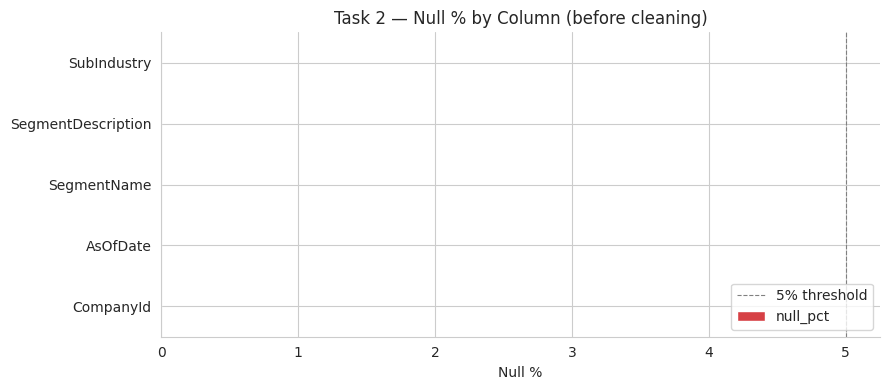

In [23]:
null_audit = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct'  : (df.isna().mean() * 100).round(2),
}).sort_values('null_pct', ascending=False)

print(null_audit.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
null_audit['null_pct'].plot(kind='barh', ax=ax, color='#d64045')
ax.axvline(5, color='gray', linestyle='--', lw=0.8, label='5% threshold')
ax.set_xlabel('Null %')
ax.set_title(f'Task {TASK} — Null % by Column (before cleaning)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 5. Drop Invalid Rows

Drop rows that cannot be salvaged:
- **Null `CompanyId`** — cannot identify the company.
- **Unparseable `AsOfDate`** — cannot place in time.
- **Out-of-range dates** — outside the spec'd window.
- **Null label** — no ground truth, cannot train or evaluate.

In [24]:
# 5a. Null CompanyId
before = len(df)
df = df.dropna(subset=['CompanyId'])
log['dropped_companyid'] = before - len(df)
print(f'Null CompanyId dropped     : {log["dropped_companyid"]:,}')

# 5b. Parse and validate dates
df['AsOfDate'] = pd.to_datetime(df['AsOfDate'], errors='coerce')
before = len(df)
df = df.dropna(subset=['AsOfDate'])
log['dropped_bad_dates'] = before - len(df)
print(f'Bad dates dropped          : {log["dropped_bad_dates"]:,}')

# 5c. Date range filter
start, end = DATE_RANGE
before = len(df)
df = df[df['AsOfDate'].between(start, end)]
log['dropped_oor_dates'] = before - len(df)
print(f'Out-of-range dates dropped : {log["dropped_oor_dates"]:,}')
print(f'Date range observed        : {df["AsOfDate"].min().date()} → {df["AsOfDate"].max().date()}')

# 5d. Null label
before = len(df)
df = df.dropna(subset=[LABEL_COL])
log['dropped_null_label'] = before - len(df)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
print(f'Null label dropped         : {log["dropped_null_label"]:,}')

print(f'\nRows remaining             : {len(df):,}')
print(f'Unique classes observed    : {df[LABEL_COL].nunique()} / {N_CLASSES}')

Null CompanyId dropped     : 0
Bad dates dropped          : 0
Out-of-range dates dropped : 0
Date range observed        : 2020-05-31 → 2024-12-31
Null label dropped         : 0

Rows remaining             : 27,537
Unique classes observed    : 428 / 450


---
## 6. Extract GECS Hierarchy (Task 1 Only)

The `MstarGlobal` code is a flat 8-digit integer that encodes the full hierarchy:

```
MstarGlobal = 10310010
  Digit 1    → Super Sector  : 1     = Cyclical
  Digits 1–3 → Sector        : 103   = Financial Services
  Digits 1–5 → Industry Group: 10310
  Full code  → Industry      : 10310010
```

Extracting these levels enables:
- Hierarchical evaluation (sector accuracy, industry accuracy, etc.)
- Hierarchical modeling (predict sector → then industry within sector)
- Better error analysis (is the model confusing within-sector or across-sector?)

In [25]:
if TASK == 1:
    code_str = df['MstarGlobal'].astype(str)
    df['super_sector_code']   = code_str.str[0]
    df['sector_code']         = code_str.str[:3]
    df['industry_group_code'] = code_str.str[:5]
    df['super_sector_name']   = df['super_sector_code'].map(SUPER_SECTOR_MAP)
    df['sector_name']         = df['sector_code'].map(SECTOR_MAP)

    print('GECS Hierarchy extracted:')
    print(f'  Super sectors  : {df["super_sector_code"].nunique()} / 3')
    print(f'  Sectors        : {df["sector_code"].nunique()} / 11')
    print(f'  Industry groups: {df["industry_group_code"].nunique()} / 55')
    print(f'  Industries     : {df[LABEL_COL].nunique()} / {N_CLASSES}')
    print(f'\nRecords per sector:')
    print(df['sector_name'].value_counts().to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    df['sector_name'].value_counts().sort_values().plot(kind='barh', ax=ax, color='#4a90d9')
    ax.set_title(f'Task {TASK} — Records per GECS Sector')
    ax.set_xlabel('Record count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
else:
    print('Task 2 — hierarchy extraction skipped (no MstarGlobal column).')

Task 2 — hierarchy extraction skipped (no MstarGlobal column).


---
## 7. Text Normalization

Steps applied to every text column:

| Step | Purpose |
|------|---------|
| HTML entity decode | `&amp;` → `&`, etc. |
| Lowercase | Case-insensitive matching (`Oil` = `oil`) |
| Remove `the company` | Morningstar's anonymization placeholder — pure noise |
| Remove URLs / emails | Not signal for industry classification |
| Strip non-ASCII | Removes accented chars and foreign-language fragments |
| Remove punctuation | Keep hyphens and commas (used in business names) |
| Collapse whitespace | Normalize multi-space / tab artifacts |
| Flag short / placeholder values as null | `nan`, `n/a`, `-` etc. become real nulls |

In [26]:
# Pre-compiled regex patterns
COMPANY_RE     = re.compile(r'\bthe company\b', flags=re.IGNORECASE)
PLACEHOLDER_RE = re.compile(r'^(nan|none|n/a|na|-|\.)$', flags=re.IGNORECASE)


def normalize_text(series: pd.Series, name: str) -> pd.Series:
    """Apply standardized text normalization pipeline to a column."""
    s = series.apply(lambda x: html.unescape(str(x)) if pd.notna(x) else x)
    s = s.str.lower()
    s = s.str.replace(COMPANY_RE, ' ', regex=True)
    s = s.str.replace(r'https?://\S+|www\.\S+', ' ', regex=True)
    s = s.str.replace(r'\S+@\S+\.\S+',         ' ', regex=True)
    s = s.str.replace(r'[^\x00-\x7F]+',          ' ', regex=True)
    s = s.str.replace(r'[^\w\s\-,]',            ' ', regex=True)
    s = s.str.strip().str.replace(r'\s+', ' ', regex=True)
    s = s.apply(
        lambda x: np.nan
        if (not isinstance(x, str)) or PLACEHOLDER_RE.fullmatch(x.strip()) or len(x.strip()) < 3
        else x
    )
    null_pct = s.isna().mean() * 100
    print(f'  {name:<22} → null after normalize: {null_pct:5.2f}%')
    return s


text_cols = ['SegmentName', 'SegmentDescription']
if TASK == 1:
    text_cols.insert(0, 'LongProfile')

print('Normalizing text columns:')
for col in text_cols:
    df[col] = normalize_text(df[col], col)

Normalizing text columns:
  SegmentName            → null after normalize:  0.03%
  SegmentDescription     → null after normalize:  0.00%


---
## 8. Fill Text Nulls

### Strategy

| Column | Task 1 Fill | Task 2 Fill |
|---|---|---|
| `SegmentName` | `[unknown segment]` | `[unknown segment]` |
| `SegmentDescription` | `LongProfile[:500] + ' ' + SegmentName` | `SegmentName` |

A **`segment_desc_missing` flag is set BEFORE filling** so the model can learn to weight
imputed text differently from real disclosures.

> **Why truncate `LongProfile` to 500 chars?** Avoids the model over-relying on
> company-level context for what is fundamentally a segment-level classification
> in Task 1. We're not using LongProfile as a substitute description — just as a hint
> when no segment description was disclosed.

In [27]:
# 8a. SegmentName — straightforward
log['seg_name_nulls'] = int(df['SegmentName'].isna().sum())
df['SegmentName']     = df['SegmentName'].fillna('[unknown segment]')
print(f'SegmentName nulls filled : {log["seg_name_nulls"]:,}')

# 8b. SegmentDescription — flag first, then fill
log['seg_desc_missing_original'] = int(df['SegmentDescription'].isna().sum())
df['segment_desc_missing']       = df['SegmentDescription'].isna().astype(int)
pct = log['seg_desc_missing_original'] / len(df) * 100
print(f'SegmentDescription originally missing : {log["seg_desc_missing_original"]:,} ({pct:.1f}%)')

fill_mask = df['SegmentDescription'].isna()
if TASK == 1:
    lp_trunc = df.loc[fill_mask, 'LongProfile'].fillna('').str[:500]
    seg_name = df.loc[fill_mask, 'SegmentName'].fillna('')
    df.loc[fill_mask, 'SegmentDescription'] = (lp_trunc + ' ' + seg_name).str.strip()
    print(f'Filled with LongProfile[:500] + SegmentName : {fill_mask.sum():,} rows')
else:
    df.loc[fill_mask, 'SegmentDescription'] = df.loc[fill_mask, 'SegmentName']
    print(f'Filled with SegmentName : {fill_mask.sum():,} rows')

log['seg_desc_filled']    = int(fill_mask.sum())
remaining                 = int(df['SegmentDescription'].isna().sum())
df['SegmentDescription']  = df['SegmentDescription'].fillna('[no description]')
print(f'Remaining {remaining} filled with [no description]')
print(f'SegmentDescription nulls final : {df["SegmentDescription"].isna().sum()}')

SegmentName nulls filled : 8
SegmentDescription originally missing : 0 (0.0%)
Filled with SegmentName : 0 rows
Remaining 0 filled with [no description]
SegmentDescription nulls final : 0


---
## 9. Fix Numeric Columns (Task 1 Only)

### Rules
- **`Revenue`, `total_revenue_company_as_of`** — coerce to numeric, set negatives to NaN.
- **`revenue_share`** — must be in [0, 1]; out-of-range values set to NaN.
  - **Recalculate** when possible from `Revenue / total_revenue` (clipped to [0, 1]).
  - **Class-median fill** for any remaining nulls (uses target leakage in cleaning, but only
    as a non-leaking imputation since we use the median, not the mean of the actual class).
- **`is_largest_share_segment`** — robust boolean parsing covering all common encodings.

In [28]:
if TASK == 1:
    # 9a. Revenue columns
    for col in ['Revenue', 'total_revenue_company_as_of']:
        df[col]      = pd.to_numeric(df[col], errors='coerce')
        neg          = int((df[col] < 0).sum())
        log_key      = 'revenue_negatives' if col == 'Revenue' else 'total_rev_negatives'
        log[log_key] = neg
        df.loc[df[col] < 0, col] = np.nan
        print(f'  {col:<32} → {neg:,} negatives → NaN')

    # 9b. revenue_share validation
    df['revenue_share']            = pd.to_numeric(df['revenue_share'], errors='coerce')
    log['rev_share_out_of_range'] = int(((df['revenue_share'] < 0) | (df['revenue_share'] > 1)).sum())
    df.loc[(df['revenue_share'] < 0) | (df['revenue_share'] > 1), 'revenue_share'] = np.nan
    print(f'  revenue_share out-of-range     : {log["rev_share_out_of_range"]:,} → NaN')

    # 9c. revenue_share recalculation
    mask = (
        df['revenue_share'].isna()
        & df['Revenue'].notna()
        & df['total_revenue_company_as_of'].notna()
        & (df['total_revenue_company_as_of'] != 0)
    )
    log['rev_share_recalculated'] = int(mask.sum())
    df.loc[mask, 'revenue_share'] = (
        df.loc[mask, 'Revenue'] / df.loc[mask, 'total_revenue_company_as_of']
    ).clip(0, 1)
    print(f'  revenue_share recalculated     : {log["rev_share_recalculated"]:,}')

    # 9d. revenue_share class-median fill
    still_null = int(df['revenue_share'].isna().sum())
    df['revenue_share'] = (
        df.groupby(LABEL_COL)['revenue_share']
          .transform(lambda x: x.fillna(x.median()))
    )
    log['rev_share_class_median'] = still_null
    print(f'  revenue_share class-median fill: {still_null:,}')

    # 9e. Robust boolean parsing for is_largest_share_segment
    BOOL_MAP = {
        'true':  True, 'false': False,
        '1':     True, '0':     False,
        'yes':   True, 'no':    False,
        'y':     True, 'n':     False,
        't':     True, 'f':     False,
    }
    raw_vals = df['is_largest_share_segment'].astype(str).str.strip().str.lower()
    mapped   = raw_vals.map(BOOL_MAP)

    log['is_largest_unmapped'] = int(
        mapped.isna().sum() - df['is_largest_share_segment'].isna().sum()
    )
    if log['is_largest_unmapped'] > 0:
        unmapped_examples = (
            raw_vals[mapped.isna() & df['is_largest_share_segment'].notna()]
            .unique()[:10]
            .tolist()
        )
        print(f'  ⚠ Unmapped is_largest values   : {unmapped_examples} ({log["is_largest_unmapped"]} rows)')

    df['is_largest_share_segment'] = mapped
    print(f'  is_largest_share_segment dist  : {df["is_largest_share_segment"].value_counts(dropna=False).to_dict()}')
else:
    print('Task 2 — no numeric columns to fix.')

Task 2 — no numeric columns to fix.


---
## 10. Drop Duplicates

| Task | Strategy | Rationale |
|---|---|---|
| 1 | Drop full-row duplicates only | Same `(CompanyId, AsOfDate, SegmentName)` legitimately differs by `Revenue`/`SegmentDescription` |
| 2 | Drop on `(CompanyId, AsOfDate, SegmentName)` | No revenue columns; same triple = same record |

In [29]:
before = len(df)
if TASK == 1:
    df = df.drop_duplicates(keep='first')
else:
    df = df.drop_duplicates(subset=['CompanyId', 'AsOfDate', 'SegmentName'], keep='first')

log['dropped_duplicates'] = before - len(df)
print(f'Dropped {log["dropped_duplicates"]:,} duplicates. Rows remaining: {len(df):,}')

Dropped 380 duplicates. Rows remaining: 27,157


---
## 11. Build `combined_text` Field

Concatenation order (most general → most specific):

- **Task 1:** `LongProfile` → `SegmentName` → `SegmentDescription`
- **Task 2:** `SegmentName` → `SegmentDescription`

This is the canonical text input for downstream TF-IDF / transformer encoders.
Rows where the result is empty are dropped (no signal at all).

In [30]:
def build_combined_text(row: pd.Series) -> str:
    """Concatenate available text fields into a single string for modeling."""
    parts = []
    if TASK == 1 and pd.notna(row.get('LongProfile')):
        parts.append(str(row['LongProfile']))
    if pd.notna(row.get('SegmentName')):
        parts.append(str(row['SegmentName']))
    if pd.notna(row.get('SegmentDescription')):
        parts.append(str(row['SegmentDescription']))
    result = ' '.join(parts).strip()
    return result if result else np.nan


df['combined_text'] = df.apply(build_combined_text, axis=1)

before                    = len(df)
df                        = df[df['combined_text'].notna()]
log['dropped_empty_text'] = before - len(df)

print(f'Dropped {log["dropped_empty_text"]:,} rows with empty combined_text')
print(f'combined_text nulls   : {df["combined_text"].isna().sum()}')
print(f'combined_text median  : {df["combined_text"].str.len().median():.0f} chars')
print(f'Rows remaining        : {len(df):,}')

Dropped 0 rows with empty combined_text
combined_text nulls   : 0
combined_text median  : 189 chars
Rows remaining        : 27,157


---
## 12. Engineer Features

Three categories of engineered columns:

1. **Length / token counts** — text length signals (a 5-word "Pharmaceuticals" segment carries
   different signal than a 500-word one).
2. **Segment-level structure** — segment count per company, segment rank by revenue (Task 1).
3. **Diagnostic columns** — prefixed `_diag_`. **Derived from the label.** Use ONLY for
   exploration / error analysis. Never feed to the model — that would be label leakage.

In [31]:
# Universal features
df['year']              = df['AsOfDate'].dt.year
df['segmentdesc_len']   = df['SegmentDescription'].str.len()
df['combined_text_len'] = df['combined_text'].str.len()
df['token_est']         = df['combined_text'].str.split().str.len()
df['segment_count']     = df.groupby(['CompanyId', 'AsOfDate'])['SegmentName'].transform('count')

# Task-specific features
if TASK == 1:
    df['longprofile_len']   = df['LongProfile'].str.len()
    df['is_single_segment'] = (df['segment_count'] == 1).astype(int)  # robust vs float comparison
    df['segment_rank']      = (
        df.groupby(['CompanyId', 'AsOfDate'])['revenue_share']
          .rank(ascending=False, method='dense')
          .astype(int)
    )

if TASK == 2:
    # ⚠ DIAGNOSTIC ONLY — derived from label. DO NOT use as model features.
    class_counts_t2          = df[LABEL_COL].value_counts()
    df['_diag_class_freq']   = df[LABEL_COL].map(class_counts_t2)
    df['_diag_class_rarity'] = pd.cut(
        df['_diag_class_freq'],
        bins=[0, 5, 30, 100, float('inf')],
        labels=['very_rare', 'rare', 'low', 'common'],
    )
    df['text_quality'] = pd.cut(
        df['combined_text_len'],
        bins=[0, 50, 100, 200, float('inf')],
        labels=['very_short', 'short', 'medium', 'long'],
    )

print(f'Features added. Final shape: {df.shape}')
print(f'\nColumn list:')
for col in df.columns:
    flag = ' ⚠ diagnostic only' if col.startswith('_diag_') else ''
    print(f'  - {col}{flag}')

Features added. Final shape: (27157, 15)

Column list:
  - CompanyId
  - AsOfDate
  - SegmentName
  - SegmentDescription
  - SubIndustry
  - segment_desc_missing
  - combined_text
  - year
  - segmentdesc_len
  - combined_text_len
  - token_est
  - segment_count
  - _diag_class_freq ⚠ diagnostic only
  - _diag_class_rarity ⚠ diagnostic only
  - text_quality


---
## 13. Numeric Scaling — *Deferred*

**Scaling is intentionally NOT performed in this notebook.**

Fitting `StandardScaler` (or any scaler) on the full dataset before train/test split causes
**data leakage** — test-set distribution statistics (mean / std) flow into training.

The correct pattern is to put the scaler inside a `Pipeline` that is `fit` only on training data:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ('num',  StandardScaler(),     numeric_features_to_scale),
    ('text', TfidfVectorizer(...), 'combined_text'),
])

pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, class_weight='balanced')),
])

pipe.fit(X_train, y_train)   # scaler fit ONLY on train ✓
```

The cell below records which columns the modeling notebook should scale.

In [32]:
if TASK == 1:
    numeric_features_to_scale = [
        'revenue_share', 'segment_count', 'longprofile_len',
        'segmentdesc_len', 'combined_text_len', 'token_est', 'year',
    ]
else:
    numeric_features_to_scale = [
        'segment_count', 'segmentdesc_len',
        'combined_text_len', 'token_est', 'year',
    ]

numeric_features_to_scale = [c for c in numeric_features_to_scale if c in df.columns]

print(f'{len(numeric_features_to_scale)} numeric features to scale in modeling pipeline:')
for c in numeric_features_to_scale:
    print(f'  - {c}')

5 numeric features to scale in modeling pipeline:
  - segment_count
  - segmentdesc_len
  - combined_text_len
  - token_est
  - year


---
## 14. Rare-Class Diagnostic

Classes with very few samples will:
- Break stratified train/test split (need ≥ 2 samples)
- Produce unstable per-class F1 scores
- Likely fall below the success criteria threshold

This cell flags how many classes are at risk.

Unique classes observed : 428 / 450
Classes absent from data : 22

Class size summary:
  min    : 1
  median : 30
  mean   : 63.5
  max    : 1,991

⚠ Risk thresholds:
  Classes with <2  samples :   21  (will break stratified split)
  Classes with <5  samples :   54  (unreliable F1)
  Classes with <30 samples :  212  (rare-class regime)


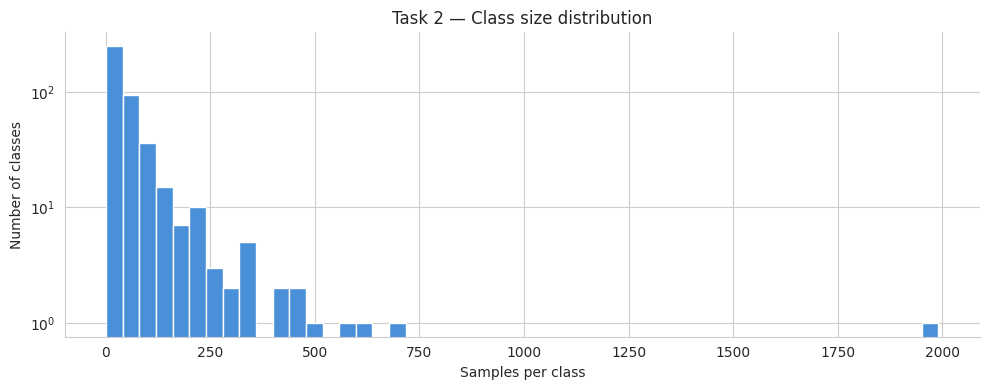

In [33]:
class_counts = df[LABEL_COL].value_counts()

print(f'Unique classes observed : {df[LABEL_COL].nunique()} / {N_CLASSES}')
print(f'Classes absent from data : {N_CLASSES - df[LABEL_COL].nunique()}')
print()
print(f'Class size summary:')
print(f'  min    : {class_counts.min():,}')
print(f'  median : {class_counts.median():,.0f}')
print(f'  mean   : {class_counts.mean():,.1f}')
print(f'  max    : {class_counts.max():,}')
print()
print(f'⚠ Risk thresholds:')
print(f'  Classes with <2  samples : {(class_counts < 2).sum():>4}  (will break stratified split)')
print(f'  Classes with <5  samples : {(class_counts < 5).sum():>4}  (unreliable F1)')
print(f'  Classes with <30 samples : {(class_counts < 30).sum():>4}  (rare-class regime)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(class_counts.values, bins=50, color='#4a90d9', edgecolor='white')
ax.set_xlabel('Samples per class')
ax.set_ylabel('Number of classes')
ax.set_title(f'Task {TASK} — Class size distribution')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## 15. Final Null Audit

In [34]:
final_nulls = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_pct'  : (df.isna().mean() * 100).round(2),
}).sort_values('null_pct', ascending=False)

non_zero = final_nulls[final_nulls['null_count'] > 0]
if len(non_zero) > 0:
    print('Columns still containing nulls:')
    print(non_zero.to_string())
else:
    print('No nulls remaining in any column ✓')

print(f'\n{len(final_nulls) - len(non_zero)} of {len(final_nulls)} columns are fully clean.')

No nulls remaining in any column ✓

15 of 15 columns are fully clean.


---
## 16. Cleaning Summary

Persist a human-readable summary alongside the cleaned data for traceability.

In [35]:
year_counts = df['AsOfDate'].dt.year.value_counts().sort_index()

lines = []
lines.append('=' * 65)
lines.append(f'  CLEANING SUMMARY v3 — Task {TASK}')
lines.append('=' * 65)

lines.append('\n--- DATASET SIZE ---')
lines.append(f'  Raw rows          : {log["raw_rows"]:,}')
lines.append(f'  Final rows        : {len(df):,}')
removed_pct = (1 - len(df) / log["raw_rows"]) * 100
lines.append(f'  Total removed     : {log["raw_rows"] - len(df):,} ({removed_pct:.1f}%)')

lines.append('\n--- ROWS DROPPED ---')
lines.append(f'  Null CompanyId    : {log["dropped_companyid"]:,}')
lines.append(f'  Bad dates         : {log["dropped_bad_dates"]:,}')
lines.append(f'  Out-of-range dates: {log["dropped_oor_dates"]:,}')
lines.append(f'  Null {LABEL_COL:<18}: {log["dropped_null_label"]:,}')
lines.append(f'  Exact duplicates  : {log["dropped_duplicates"]:,}')
lines.append(f'  Empty text        : {log["dropped_empty_text"]:,}')

lines.append('\n--- TEXT FIXES ---')
lines.append(f'  SegmentName nulls           : {log["seg_name_nulls"]:,} → [unknown segment]')
lines.append(f'  SegmentDesc originally null : {log["seg_desc_missing_original"]:,}')
lines.append(f'  SegmentDesc filled          : {log["seg_desc_filled"]:,}')
if TASK == 1:
    lines.append(f'  Fill method                 : LongProfile[:500] + SegmentName')
else:
    lines.append(f'  Fill method                 : SegmentName')
lines.append(f'  Text normalized             : lowercase, removed "the company", cleaned punctuation')

if TASK == 1:
    lines.append('\n--- NUMERIC FIXES ---')
    lines.append(f'  Revenue negatives → NaN     : {log["revenue_negatives"]:,}')
    lines.append(f'  total_rev negatives → NaN   : {log["total_rev_negatives"]:,}')
    lines.append(f'  rev_share out-of-range      : {log["rev_share_out_of_range"]:,}')
    lines.append(f'  rev_share recalculated      : {log["rev_share_recalculated"]:,}')
    lines.append(f'  rev_share class median fill : {log["rev_share_class_median"]:,}')
    lines.append(f'  is_largest unmapped values  : {log["is_largest_unmapped"]:,}')
    lines.append(f'  Numeric scaling             : DEFERRED to modeling notebook (prevents leakage)')

    lines.append('\n--- HIERARCHY EXTRACTED ---')
    lines.append(f'  Super sectors  : {df["super_sector_code"].nunique()} of 3')
    lines.append(f'  Sectors        : {df["sector_code"].nunique()} of 11')
    lines.append(f'  Industry groups: {df["industry_group_code"].nunique()} of 55')
    lines.append(f'  Industries     : {df[LABEL_COL].nunique()} of 145')
    lines.append(f'  Sector distribution:')
    for sector, count in df['sector_name'].value_counts().items():
        lines.append(f'    {sector:<30} : {count:,}')

lines.append('\n--- CLASS DISTRIBUTION ---')
lines.append(f'  Unique classes   : {df[LABEL_COL].nunique()} / {N_CLASSES}')
lines.append(f'  Most common      : {class_counts.index[0]} — {class_counts.iloc[0]:,}')
lines.append(f'  Least common     : {class_counts.index[-1]} — {class_counts.iloc[-1]:,}')
lines.append(f'  Imbalance ratio  : {class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x')
lines.append(f'  Classes with <2 samples : {(class_counts < 2).sum()}  (breaks stratified split)')
lines.append(f'  Classes with <5 samples : {(class_counts < 5).sum()}  (unreliable F1)')

lines.append('\n--- TEXT STATS ---')
for col in text_cols:
    med = df[col].dropna().str.len().median()
    lines.append(f'  {col:<22} median: {int(med)} chars')
lines.append(f'  combined_text          median: {int(df["combined_text"].str.len().median())} chars')
lines.append(f'  token_est              median: {df["token_est"].median():.0f} words')

lines.append('\n--- FINAL NULL AUDIT ---')
for col, row in final_nulls.iterrows():
    if row['null_count'] == 0:
        status = '✓'
    elif row['null_pct'] > 5:
        status = '⚠'
    else:
        status = '~'
    lines.append(f'  {status} {col:<35} {int(row["null_count"]):>6} ({row["null_pct"]:.2f}%)')

lines.append('\n' + '=' * 65)
full_summary = '\n'.join(lines)
print(full_summary)

# Persist to disk
with open(SUMMARY_PATH, 'w') as f:
    f.write(full_summary)
print(f'\nSummary saved to: {SUMMARY_PATH}')

  CLEANING SUMMARY v3 — Task 2

--- DATASET SIZE ---
  Raw rows          : 27,537
  Final rows        : 27,157
  Total removed     : 380 (1.4%)

--- ROWS DROPPED ---
  Null CompanyId    : 0
  Bad dates         : 0
  Out-of-range dates: 0
  Null SubIndustry       : 0
  Exact duplicates  : 380
  Empty text        : 0

--- TEXT FIXES ---
  SegmentName nulls           : 8 → [unknown segment]
  SegmentDesc originally null : 0
  SegmentDesc filled          : 0
  Fill method                 : SegmentName
  Text normalized             : lowercase, removed "the company", cleaned punctuation

--- CLASS DISTRIBUTION ---
  Unique classes   : 428 / 450
  Most common      : 3103001001 — 1,991
  Least common     : 1014001003 — 1
  Imbalance ratio  : 1991.0x
  Classes with <2 samples : 21  (breaks stratified split)
  Classes with <5 samples : 54  (unreliable F1)

--- TEXT STATS ---
  SegmentName            median: 17 chars
  SegmentDescription     median: 168 chars
  combined_text          median: 189

---
## 17. Save Cleaned Data

Saved as **parquet** for fast loading and dtype preservation. Falls back to CSV if `pyarrow`
is not installed.

In [38]:
try:
    df.to_parquet(OUTPUT_PATH, index=False, engine='pyarrow', compression='snappy')
    print(f'Saved   : {OUTPUT_PATH}')
    print(f'Format  : parquet (snappy compression)')
except ImportError:
    csv_path = str(OUTPUT_PATH).replace('.parquet', '.csv')
    df.to_csv(csv_path, index=False, encoding='utf-8')
    print(f'pyarrow not installed — saved as CSV instead: {csv_path}')
    print(f'  → install with: pip install pyarrow')

print(f'Shape   : {df.shape}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB in-memory')

print(f'\nColumns ({len(df.columns)}):')
for c in df.columns:
    print(f'  - {c}')

pyarrow not installed — saved as CSV instead: ../data/cleaned/task2_subindustry_classification_final_cleaned.csv
  → install with: pip install pyarrow
Shape   : (27157, 15)
Memory  : 21.3 MB in-memory

Columns (15):
  - CompanyId
  - AsOfDate
  - SegmentName
  - SegmentDescription
  - SubIndustry
  - segment_desc_missing
  - combined_text
  - year
  - segmentdesc_len
  - combined_text_len
  - token_est
  - segment_count
  - _diag_class_freq
  - _diag_class_rarity
  - text_quality


---
## Next Steps

1. **Run this notebook for both `TASK = 1` and `TASK = 2`** to produce both cleaned files.
2. **`02_eda.ipynb`** — exploratory analysis on the cleaned data: class distributions, text
   length distributions, sector/industry imbalance.
3. **`03_baseline.ipynb`** — TF-IDF + Logistic Regression baseline. This is the floor — every
   subsequent model has to beat it on macro-F1 to justify its complexity.
4. **`04_modeling.ipynb`** — sentence-transformer embeddings, fine-tuned encoders, hierarchical
   modeling experiments.
5. **`05_evaluation.ipynb`** — confusion analysis, error analysis, cost/quality comparison.